### Exercises

#### Exercise 1

##### Part 1

Read in the dataset in `fuel.csv`. Inspect the distribution of the response variable `fuel_consumption`.

<Axes: xlabel='fuel_consumption', ylabel='Count'>

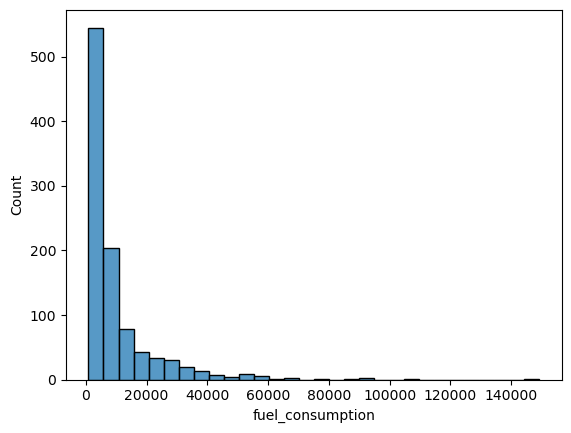

In [21]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("../data/fuel.csv")
sns.histplot(data=df, x="fuel_consumption", bins=30)

##### Part 2

Determine whether a transformation should be applied to the response to make its distribution appear more normal. Apply that transformation and then inspect the distribution of the transformed response variable.

<Axes: xlabel='log_fuel_consumption', ylabel='Count'>

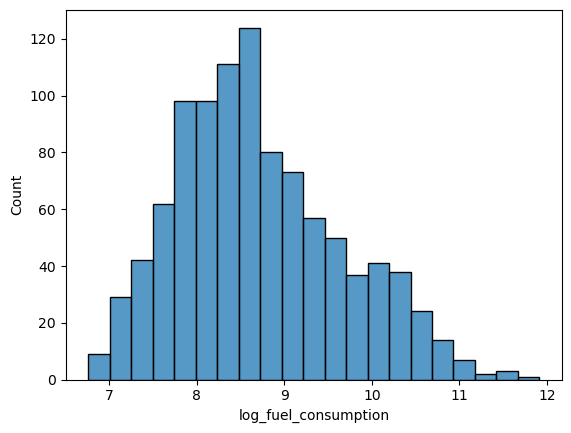

In [22]:
df["log_fuel_consumption"] = np.log(df["fuel_consumption"]+1)
sns.histplot(data=df, x="log_fuel_consumption")

#### Exercise 2

##### Part 1

Select a quantitative predictor that you believe would be useful in modeling the response variable. Provide a numeric summary or visualization to justify this choice.

<Axes: xlabel='flight_distance', ylabel='log_fuel_consumption'>

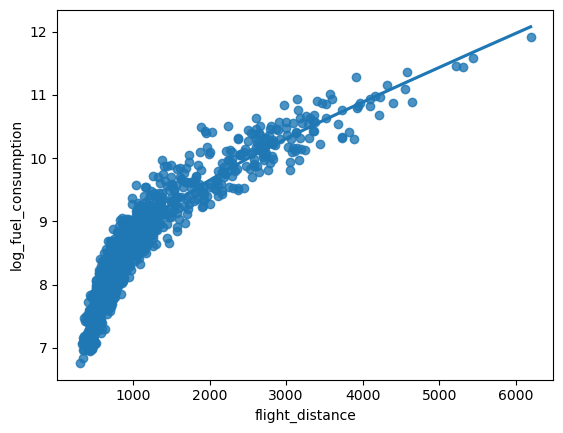

In [23]:
sns.regplot(data=df, x="flight_distance", y="log_fuel_consumption", lowess=True)

##### Part 2

Determine if a transformation should be applied to the predictor to achieve a more linear relationship between the response and the predictor. If a transformation is necessary, apply the transformation and provide another summary or visualization to demonstrate the effect of this transformation.

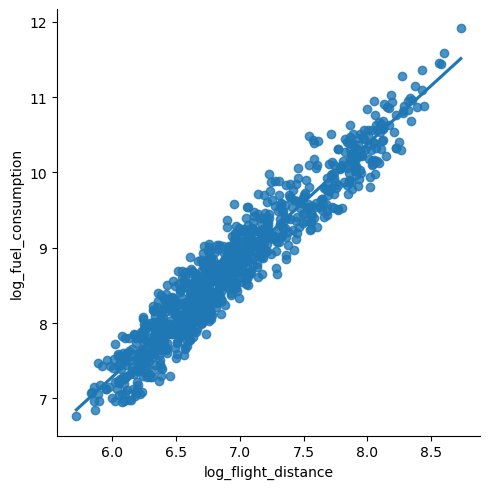

In [24]:
df["log_flight_distance"] = np.log(df["flight_distance"]+1)
sns.lmplot(data=df, x="log_flight_distance", y="log_fuel_consumption", ci=False)

#### Exercise 3

##### Part 1

Use the `sklearn` library to fit a simple linear regression model using your predictor and response variable. Output the intercept and slope of the fitted model.

In [25]:
from sklearn.linear_model import LinearRegression
slr_model = LinearRegression()
X_slr = df[["log_flight_distance"]]
y = df["log_fuel_consumption"]
slr_model.fit(X_slr, y)
print("Intercept: ", slr_model.intercept_)
print("Slope: ", slr_model.coef_)

Intercept:  -2.0109690307396324
Slope:  [1.54878226]


##### Part 2

Write out the regression equation for the fitted model and interpret the intercept and slope in context.

y_hat = -2.01 + 1.55x_i  
The base amount of log fuel consumed is -2.01 units and every log flight distance unit traveled further uses 1.55 units

#### Exercise 4

##### Part 1

Investigate relationships with other quantitative variables and the response. Identify several other quantitative variables you could include in your model. Provide a numeric summary or visualization justifying these choices.

C:\Users\simpl\miniconda3\envs\tstat280\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


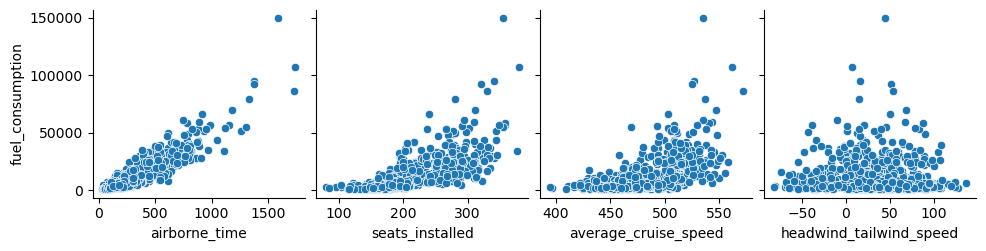

In [26]:
df["log_airborne_time"] = np.log(df["airborne_time"]+1)
df["log_seats_installed"] = np.log(df["seats_installed"]+1)
df["log_average_cruise_speed"] = np.log(df["average_cruise_speed"]+1)
df["log_headwind_tailwind_speed"] = np.log(df["headwind_tailwind_speed"]+1)

sns.pairplot(data=df, x_vars=["airborne_time", "seats_installed", "average_cruise_speed", "headwind_tailwind_speed"], y_vars="fuel_consumption")

##### Part 2

Use the `sklearn` library to fit a multiple linear regression model with the other selected quantitative variables. Output the intercept and slope coefficients.

In [27]:
airspeed_model = LinearRegression()
X_airspeed = df[["log_airborne_time", "log_average_cruise_speed"]]
y = df["log_fuel_consumption"]
airspeed_model = airspeed_model.fit(X_airspeed, y)
print("Intercept: ", airspeed_model.intercept_)
print("Slope: ", airspeed_model.coef_)

Intercept:  -13.150814003842612
Slope:  [1.10317971 2.58507289]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.

airspeed_model = -13.15 + 1.10(log_airborne_time) + 2.59(log_average_cruise_speed)  
The base amount of airspeed is -13.15 and increases by 1.10 per unit of log airborne time and increases by 2.59 per unit of log average cruise speed

#### Exercise 5

##### Part 1

Identify one or more categorical variables that could be useful in predicting the response variable. Provide a numeric summary or visualization to justify these choices of categorical variables.

Index(['season', 'departure_airport', 'cloud_type', 'jet_stream_region',
       'arrival_congestion', 'aircraft_type', 'upholstery_style',
       'engine_model', 'manufacturer_country', 'terminal_architecture',
       'flight_distance', 'takeoff_weight', 'payload_weight',
       'cruise_altitude', 'average_cruise_speed', 'headwind_tailwind_speed',
       'taxi_out_time', 'airborne_time', 'outside_air_temperature',
       'holding_time', 'ife_screens', 'seats_installed',
       'checked_baggage_count', 'cabin_pressurization_setting',
       'scheduled_arrival_buffer', 'departure_runways', 'meal_services',
       'fuel_consumption', 'log_fuel_consumption', 'log_flight_distance',
       'log_airborne_time', 'log_seats_installed', 'log_average_cruise_speed',
       'log_headwind_tailwind_speed', 'weather_condition_Rain',
       'weather_condition_Snow', 'weather_condition_Storm'],
      dtype='object')

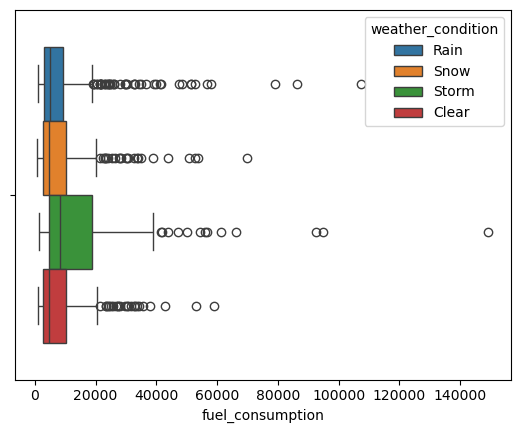

In [28]:
sns.boxplot(data=df, x="fuel_consumption", hue="weather_condition")

df = pd.get_dummies(data=df, columns=["weather_condition"], drop_first=True, dtype="int")
df.columns

##### Part 2

Use the `sklearn` library to fit a multiple linear regression model including the selected categorical variables and any relevant quantitative variables. Output the intercept and slope coefficients.

In [29]:
fuel_model = LinearRegression()
X_fuel = df[["weather_condition_Rain", "weather_condition_Snow", "weather_condition_Storm", "log_airborne_time"]]
y = df["log_fuel_consumption"]
fuel_model = fuel_model.fit(X_fuel, y)
print("Intercept: ", fuel_model.intercept_)
print("Slope: ", fuel_model.coef_)

Intercept:  2.1463678820229894
Slope:  [0.01372162 0.07044073 0.19442498 1.21609177]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.

fuel_model = 2.15 + 0.01(weather_condition_Rain) + 0.07(weather_condition_Snow) + 0.19(weather_condition_Storm) + 1.22(log_airborne_time)
The base fuel used is 2.15 units, and increases by 0.01 units for the amount of rain, 0.07 units for the amount of snow, 0.19 for the amount of storms, and 1.22 units per log of airborne time

#### Exercise 6

##### Part 1

Compute RMSE and $R^2$ for all of the previously fitted models.

In [31]:
from sklearn.metrics import root_mean_squared_error, r2_score
slr_preds = slr_model.predict(X_slr)
airspeed_preds = airspeed_model.predict(X_airspeed)
fuel_preds = fuel_model.predict(X_fuel)

print("SLR RMSE: ", root_mean_squared_error(slr_preds, y))
print("AIRSPEED RMSE: ", root_mean_squared_error(airspeed_preds, y))
print("FUEL RMSE: ", root_mean_squared_error(fuel_preds, y))

print("SLR R2: ", r2_score(slr_preds, y))
print("AIRSPEED R2: ", r2_score(airspeed_preds, y))
print("FUEL R2: ", r2_score(fuel_preds, y))

SLR RMSE:  0.2651437120873705
AIRSPEED RMSE:  0.39394214324884386
FUEL RMSE:  0.40520862292231236
SLR R2:  0.9147933181785819
AIRSPEED R2:  0.790333485801686
FUEL R2:  0.7754377481888568


##### Part 2

Keeping in mind that we want to find models that have high predictive power, but are relatively simple, which of the competing models would you select?

SLR model because its RMSE is the smallest and its r2 is the closest to 1

#### Exercise 7

##### Part 1

Produce a numeric summary or visualization that allows you to investigate any instances of multicollinearity.

<Axes: xlabel='log_fuel_consumption', ylabel='log_flight_distance'>

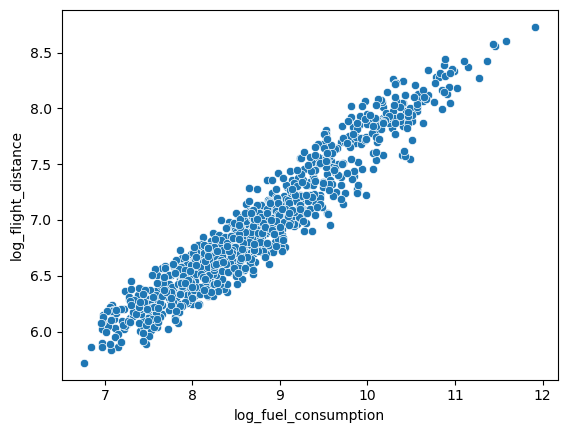

In [35]:
sns.scatterplot(data=df, x="log_fuel_consumption", y="log_flight_distance")

##### Part 2

Describe any instances of multicollinearity that you discovered.

Flight traveled seems to have multicollinearity with fuel consumption

#### Exercise 8


##### Part 1

Create a plot of the fitted values $\hat{y}_i$ versus the residuals $y_i - \hat{y}_i$.

<Axes: ylabel='log_fuel_consumption'>

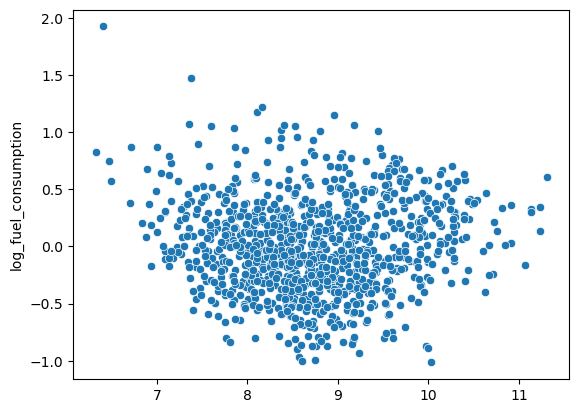

In [36]:
resids = y - fuel_preds
sns.scatterplot(x = fuel_preds, y = resids)

##### Part 2

Using the plot of fitted values versus residuals, do there appear to be any violations of the assumption of linearity?

YOUR ANSWER HERE

#### Exercise 9

##### Part 1

Plot the residuals $y_i-\hat{y}_i$ against other potentially useful predictors that haven't already been included in the model.

##### Part 2

Based on the plots of residuals versus other predictors, do their appear to be any other predictors that should be included in the model?

YOUR ANSWER HERE

#### Exercise 10

##### Part 1

Using everything you've learned so far, fit a final model that you would use to predict the response. Report the intercept and coefficients for this final model.

In [14]:
# YOUR CODE HERE

##### Part 2

Report the regression equation for your final model.

YOUR ANSWER HERE